In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout


In [58]:
import matplotlib.pyplot as plt
import tensorflow as tf


In [59]:
import matplotlib.pyplot as plt


In [60]:
import sys
print(sys.executable)


c:\Users\Abhishek Shet\AppData\Local\Programs\Python\Python312\python.exe


In [61]:
train_path=r"D:\MCA_ALLIANCE_UN\ABHI_AI\Traffic_Light\Traffic_Light\train"
test_path=r"D:\MCA_ALLIANCE_UN\ABHI_AI\Traffic_Light\Traffic_Light\test"

In [62]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1/255)

In [63]:
train_generator=train_datagen.flow_from_directory(
    train_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    classes=['Green','Red','Yellow']
)

test_generator=test_datagen.flow_from_directory(
    test_path,
    target_size=(64,64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False,
    classes=['Green','Red','Yellow']
)
print('train classes:', train_generator.class_indices)
print('test classes:', test_generator.class_indices)

Found 300 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
train classes: {'Green': 0, 'Red': 1, 'Yellow': 2}
test classes: {'Green': 0, 'Red': 1, 'Yellow': 2}


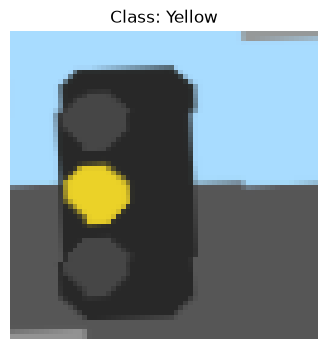

In [64]:
# Display one sample image
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images
image, labels = next(train_generator)

# Display the first image
plt.figure(figsize=(4, 4))
plt.imshow(image[0])
plt.title("Class: " + list(train_generator.class_indices.keys())[np.argmax(labels[0])])
plt.axis("off")
plt.show()

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax'),
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,587 (2.61 MB)

 Trainable params: 683,587 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [67]:
print('model output shape:', model.output_shape)
print('train class indices:', train_generator.class_indices)
image_batch, label_batch = next(train_generator)
print('image batch shape:', image_batch.shape)
print('label batch shape:', label_batch.shape)
print('label sample:', label_batch[0])

model output shape: (None, 3)
train class indices: {'Green': 0, 'Red': 1, 'Yellow': 2}
image batch shape: (32, 64, 64, 3)
label batch shape: (32, 3)
label sample: [0. 1. 0.]


In [68]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.5367 - loss: 0.9275 - val_accuracy: 1.0000 - val_loss: 0.3138
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 1.0000 - loss: 0.0785 - val_accuracy: 1.0000 - val_loss: 3.7486e-04
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9933 - loss: 0.0180 - val_accuracy: 1.0000 - val_loss: 1.2119e-06
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 1.7404e-06
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 1.0000 - loss: 6.8698e-04 - val_accuracy: 1.0000 - val_loss: 1.1325e-07
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 1.0000 - loss: 3.0254e-04 - val_accuracy: 1.0000 - val_loss: 1.5895e-08
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 1.0000 - loss: 1.7839e-04 - val_accuracy: 1.0000 - val_loss: 3.9736e-09
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 1.0000 - lo

In [70]:
loss, accuracy = model.evaluate(test_generator)
print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 7.9473e-08
Test Accuracy: 1.0


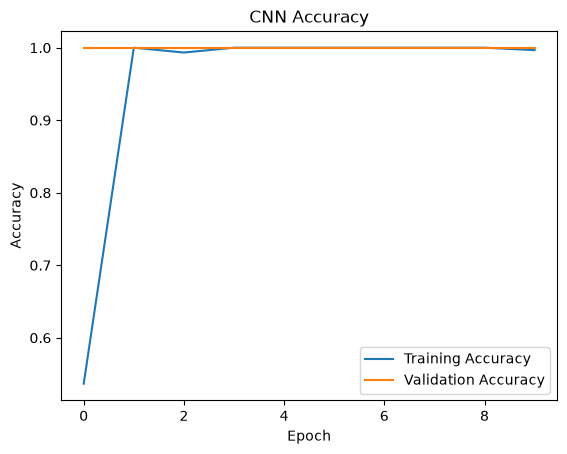

In [71]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()